# **Lab 6 Hyperparameter Tuning**

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset,Dataset

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import os
import cv2
from skimage.util import random_noise
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Ray Tune imports may fail if optional dependencies (pandas, pyarrow, etc.) are missing.
# Gracefully handle that and provide instructions instead of crashing the notebook.
try:
    import ray
    from ray import tune
    from ray.air import session
    RAY_AVAILABLE = True
except Exception as e:
    RAY_AVAILABLE = False
    # Keep names defined to avoid NameError elsewhere in the notebook
    ray = None
    tune = None
    session = None
    print("Warning: Ray (or Ray Tune) could not be imported. Some cells that rely on Ray will be skipped.")
    print("Import error:", e)

    def ensure_ray_install_instructions():
        print("To enable Ray Tune, install required packages in your environment.")
        print("Recommended (pip): pip install 'ray[tune]' pandas pyarrow fsspec")
        print("If using conda, first activate your env, then: conda install pandas && pip install 'ray[tune]' pyarrow fsspec")

seed = 4912
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## Data Preparation
Complete the class `CustomImageDataset()` that `__getitem__` return ***noisy blury*** image and ***ground truth*** image.
Please ensure that the final image is in RGBscale and has a size of 128x128.

In [52]:
### START CODE HERE ###
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, gauss_noise=False, gauss_blur=None, resize=128, p=0.5):
        self.p = p
        self.resize = resize
        self.gauss_noise = gauss_noise
        self.gauss_blur = gauss_blur
        self.image_paths = image_paths
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        # Read image using cv2
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Resize to 128x128
        img = cv2.resize(img, (self.resize, self.resize))
        gt_image = img.copy()
        # Apply Gaussian blur if specified
        if self.gauss_blur is not None:
            if np.random.rand() < self.p:
                img = cv2.GaussianBlur(img, (self.gauss_blur, self.gauss_blur), 0)
        # Apply Gaussian noise if specified
        if self.gauss_noise:
            if np.random.rand() < self.p:
                img = random_noise(img, mode='gaussian', clip=True)
                img = (img * 255).astype(np.uint8)
        # Convert to tensor and normalize to [0,1]
        img = torch.from_numpy(img).float().permute(2, 0, 1) / 255.0
        gt_image = torch.from_numpy(gt_image).float().permute(2, 0, 1) / 255.0
        return img, gt_image
### END CODE HERE ###

In [53]:
### START CODE HERE ###
def imshow_grid(images, nrow=4, title=None):
    images = images.cpu().numpy() if hasattr(images, 'cpu') else images
    batch_size = images.shape[0] if len(images.shape) == 4 else 1
    fig, axs = plt.subplots(1, min(nrow, batch_size), figsize=(12, 3))
    for i in range(min(nrow, batch_size)):
        img = images[i].transpose(1,2,0) if len(images.shape) == 4 else images.transpose(1,2,0)
        axs[i].imshow(np.clip(img, 0, 1))
        axs[i].axis('off')
    if title:
        plt.suptitle(title)
    plt.show()
### END CODE HERE ###

In [54]:
### START CODE HERE ###
data_dir = r"c:/Users/IMG_PRO/Desktop/Image-Processing-Course-2025/Lab6_Hyperparameter-Tuning/assets/img_align_celeba"
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Data directory not found: {data_dir}")
files = [os.path.join(data_dir, file) for file in os.listdir(data_dir) if file.endswith('.jpg')]
train_files, test_files = train_test_split(files, test_size=0.2, random_state=4912)
train_dataset = CustomImageDataset(train_files, gauss_noise=True, gauss_blur=5, resize=128, p=0.5)
test_dataset = CustomImageDataset(test_files, gauss_noise=True, gauss_blur=5, resize=128, p=0.5)
trainloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=16, shuffle=False)
### END CODE HERE ###

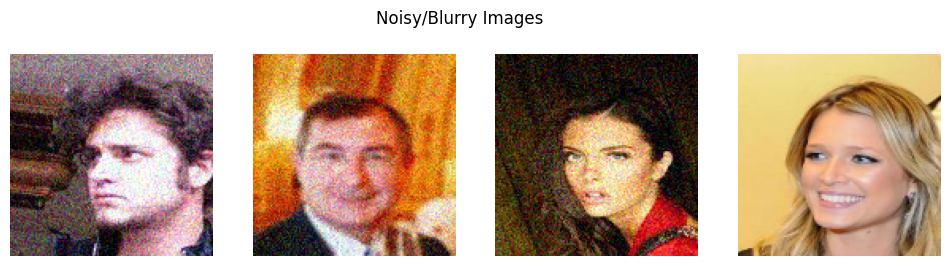

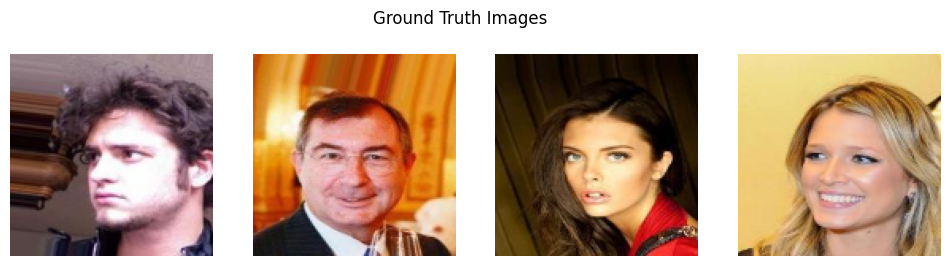

In [55]:
### START CODE HERE ###
batch, gt_img = next(iter(trainloader))
imshow_grid(batch, nrow=4, title="Noisy/Blurry Images")
imshow_grid(gt_img, nrow=4, title="Ground Truth Images")
### END CODE HERE ###

## Create Autoencoder model
You can design your own Autoencoder model with a customizable number of downsampling and upsampling blocks by passing a list of channel numbers for each layer based on the provided code below. However, please maintain the concept of 'Autoencoder'.

In [56]:
### START CODE HERE ###
class DownSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(DownSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

class UpSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(UpSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.upsample(x)
        return x

class Autoencoder(nn.Module):
    def __init__(self, channels=[64, 128, 256], input_channels=3, output_channels=3):
        super().__init__()
        # Encoder
        self.encoder_blocks = nn.ModuleList()
        in_ch = input_channels
        for ch in channels:
            self.encoder_blocks.append(DownSamplingBlock(in_ch, ch))
            in_ch = ch
        # Decoder
        self.decoder_blocks = nn.ModuleList()
        for ch in reversed(channels):
            self.decoder_blocks.append(UpSamplingBlock(in_ch, ch))
            in_ch = ch
        self.final_conv = nn.Conv2d(in_ch, output_channels, kernel_size=3, stride=1, padding=1)
        self.final_act = nn.Sigmoid()
    def forward(self, x):
        for block in self.encoder_blocks:
            x = block(x)
        for block in self.decoder_blocks:
            x = block(x)
        x = self.final_conv(x)
        x = self.final_act(x)
        return x
### END CODE HERE ###

## Train Autoencoder
Complete the `train()` function in the cell below. This function should evaluate the model at every epoch, log the ***training loss, test loss,test PSNR, test SSIM***. Additionally, it should save the model at the last epoch.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The log should resemble this, but not be identical

```
🤖Training on cuda
🚀Training Epoch [1/1]: 100%|██████████| 1313/1313 [01:45<00:00, 12.41batch/s, loss=0.0102] 
📄Testing: 100%|██████████| 563/563 [01:10<00:00,  7.95batch/s, loss=0.0106, psnr=16.7, ssim=0.348] 
Summary :
	Train	avg_loss: 0.017262999383663165
	Test	avg_loss: 0.010476540363861867 
                PSNR : 16.839487147468034 
                SSIM : 0.36090552368883694
...
```

</details>

Resource : [PyTorch Training loop](<https://pytorch.org/tutorials/beginner/introyt/trainingyt.html#:~:text=%3D0.9)-,The%20Training%20Loop,-Below%2C%20we%20have>), [PSNR & SSIM](https://ieeexplore.ieee.org/document/5596999)

In [57]:
### START CODE HERE ###
def train(model,opt,loss_fn,train_loader,test_loader,epochs=10,checkpoint_path=None,device='cpu'):
    print("🤖Training on", device)
    model = model.to(device)
    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_bar = tqdm(train_loader,desc=f'🚀Training Epoch [{epoch+1}/{epochs}]',unit='batch')
        for images, gt in train_bar:
            images, gt = images.to(device), gt.to(device)
            opt.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, gt)
            loss.backward()
            opt.step()
            train_losses.append(loss.item())
            train_bar.set_postfix(loss=f"{loss.item():.4f}")
        avg_train_loss = np.mean(train_losses)
        model.eval()
        test_losses = []
        psnr_scores = []
        ssim_scores = []
        test_bar = tqdm(test_loader,desc='📄Testing',unit='batch')
        with torch.no_grad():
            for images, gt in test_bar:
                images, gt = images.to(device), gt.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, gt)
                test_losses.append(loss.item())
                # Convert to numpy for metric calculation
                out_np = outputs.cpu().numpy()
                gt_np = gt.cpu().numpy()
                for i in range(out_np.shape[0]):
                    psnr_scores.append(psnr(gt_np[i], out_np[i], data_range=1.0))
                    ssim_scores.append(ssim(gt_np[i].transpose(1,2,0), out_np[i].transpose(1,2,0), win_size=7, channel_axis=2, data_range=1.0))
                test_bar.set_postfix(loss=f"{loss.item():.4f}", psnr=f"{np.mean(psnr_scores):.2f}", ssim=f"{np.mean(ssim_scores):.3f}")
        avg_test_loss = np.mean(test_losses)
        avg_psnr = np.mean(psnr_scores)
        avg_ssim = np.mean(ssim_scores)
        print("Summary :")
        print(f"\tTrain\tavg_loss: {avg_train_loss}")
        print(f"\tTest\tavg_loss: {avg_test_loss}")
        print(f"\t\tPSNR : {avg_psnr}")
        print(f"\t\tSSIM : {avg_ssim}")
        if checkpoint_path and (epoch == epochs-1):
            torch.save(model.state_dict(), checkpoint_path)
### END CODE HERE ###

Let's train your model with 2 epochs to verify that your train() function works properly. After that, we'll move on to the Hyperparameter Grid Search in the next part.

In [58]:
### START CODE HERE ###
data_dir = r"c:/Users/IMG_PRO/Desktop/Image-Processing-Course-2025/Lab6_Hyperparameter-Tuning/assets/img_align_celeba"
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Data directory not found: {data_dir}")
files = [os.path.join(data_dir, file) for file in os.listdir(data_dir) if file.endswith('.jpg')]
train_files, test_files = train_test_split(files, test_size=0.2, random_state=4912)
train_dataset = CustomImageDataset(train_files, gauss_noise=True, gauss_blur=5, resize=128, p=0.5)
test_dataset = CustomImageDataset(test_files, gauss_noise=True, gauss_blur=5, resize=128, p=0.5)
trainloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=16, shuffle=False)
### END CODE HERE ###

In [59]:
### START CODE HERE ###
model = Autoencoder(channels=[64, 128, 256], input_channels=3, output_channels=3)
opt = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
train(model, opt, loss_fn, trainloader, testloader, epochs=2, checkpoint_path="autoencoder_test.pth", device='cuda' if torch.cuda.is_available() else 'cpu')
### END CODE HERE ###

🤖Training on cuda


📄Testing: 100%|██████████| 34/34 [00:01<00:00, 19.73batch/s, loss=0.0183, psnr=17.53, ssim=0.509]


Summary :
	Train	avg_loss: 0.015693513283299074
	Test	avg_loss: 0.01904148915234734
		PSNR : 17.52795301485433
		SSIM : 0.5086559057235718


📄Testing: 100%|██████████| 34/34 [00:01<00:00, 20.71batch/s, loss=0.0112, psnr=19.88, ssim=0.543]

Summary :
	Train	avg_loss: 0.010304268929003565
	Test	avg_loss: 0.010830068686867462
		PSNR : 19.876211877600454
		SSIM : 0.5427749752998352


---

## **Hyperparameter Grid Search with Raytune**

*If you have access to APEX, I would recommend converting this part into a Python file and submitting the job to run on APEX using SBATCH. This process may take a considerable amount of time.*

You can import additional Ray Tune tools as you want, such as schedulers, search algorithms, etc. Further information on the usage of Ray Tune can be found [here](https://docs.ray.io/en/latest/tune/index.html).

In [60]:
### START CODE HERE ###
# Guarded Ray shutdown — only call if Ray was successfully imported earlier
if RAY_AVAILABLE:
    try:
        ray.shutdown()
        print("Ray shutdown (if it was running).")
    except Exception as e:
        print("Warning: ray.shutdown() failed:", e)
else:
    print("Ray not available in this environment. Skipping ray.shutdown().")
    ensure_ray_install_instructions()
### END CODE HERE ###

Ray shutdown (if it was running).


Complete the `train_raytune()` function below, following the [quick start guide](https://docs.ray.io/en/latest/tune/index.html). This function will be passed to the `tune.Tuner`.

In [61]:
### START CODE HERE ###
def train_raytune(config):
    # Prepare data
    data_dir = r"./Lab6_Hyperparameter-Tuning/assets/img_align_celeba"
    files = [os.path.join(data_dir, file) for file in os.listdir(data_dir) if file.endswith('.jpg')]
    train_files, test_files = train_test_split(files, test_size=0.2, random_state=4912)
    train_dataset = CustomImageDataset(train_files, gauss_noise=True, gauss_blur=5, resize=128, p=0.5)
    test_dataset = CustomImageDataset(test_files, gauss_noise=True, gauss_blur=5, resize=128, p=0.5)
    trainloader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    testloader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)
    # Model
    model = Autoencoder(channels=config['architecture'], input_channels=3, output_channels=3)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    # Optimizer
    if config['optimizer'] == 'Adam':
        opt = optim.Adam(model.parameters(), lr=config['lr'])
    elif config['optimizer'] == 'SGD':
        opt = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9)
    loss_fn = nn.MSELoss()
    for epoch in range(config['num_epochs']):
        model.train()
        train_losses = []
        for images, gt in trainloader:
            images, gt = images.to(device), gt.to(device)
            opt.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, gt)
            loss.backward()
            opt.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        model.eval()
        test_losses = []
        psnr_scores = []
        ssim_scores = []
        with torch.no_grad():
            for images, gt in testloader:
                images, gt = images.to(device), gt.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, gt)
                test_losses.append(loss.item())
                out_np = outputs.cpu().numpy()
                gt_np = gt.cpu().numpy()
                for i in range(out_np.shape[0]):
                    # out_np and gt_np are in [0,1], shape (C,H,W)
                    psnr_scores.append(psnr(gt_np[i], out_np[i], data_range=1.0))
                    ssim_scores.append(ssim(gt_np[i].transpose(1,2,0), out_np[i].transpose(1,2,0), win_size=7, channel_axis=2, data_range=1.0))
        avg_test_loss = np.mean(test_losses) if len(test_losses)>0 else float('nan')
        avg_psnr = np.mean(psnr_scores) if len(psnr_scores)>0 else float('nan')
        avg_ssim = np.mean(ssim_scores) if len(ssim_scores)>0 else float('nan')
        session.report({
            "train_loss": avg_train_loss,
            "val_loss": avg_test_loss,
            "val_psnr": avg_psnr,
            "val_ssim": avg_ssim,
        })
### END CODE HERE ###

Initialize Ray, define the search space, and resources.

Resource : 
- [A Guide To Parallelism and Resources for Ray Tune](https://docs.ray.io/en/latest/tune/tutorials/tune-resources.html#:~:text=A%20Guide%20To%20Parallelism%20and%20Resources%20for%20Ray%20Tune) 
- [Working with Tune Search Spaces](https://docs.ray.io/en/latest/tune/tutorials/tune-search-spaces.html#tune-search-space-tutorial:~:text=Working%20with%20Tune%20Search%20Spaces)
- [How to configure logging in Tune?](https://docs.ray.io/en/latest/tune/tutorials/tune-output.html) 
- [Tune Trial Schedulers (`tune.schedulers`)](https://docs.ray.io/en/latest/tune/api/schedulers.html#tune-scheduler-pbt:~:text=Tune%20Trial...-,Tune%20Trial%20Schedulers%20(tune.schedulers),-%23)

**Search Space:**
- `architecture`:<br>
    Feature map dimensions for convolutional layers<br>
    - `[32, 64, 128]`: 3 downsampling layers with feature maps increasing from 32 to 128.
    - `[64, 128, 256]`: 3 downsampling layers with feature maps starting from 64 to 256.
    - `[64, 128, 256, 512]`: 4 downsampling layers with more depth, starting from 64 and ending at 512.
- `learning rates (lr)`:
    - [1e-3, 8e-4, 1e-4, 1e-2]: Test a wide range of learning rates to evaluate model performance, from 1e-3 (typical) to a more aggressive 1e-2 or conservative 1e-4.
- `batch size`:
    - [16, 32]: Explore smaller batch sizes to evaluate their impact on gradient estimation and memory usage.
- `number of epochs`:
    - `[10, 50, 100]`: Allow short and long training sessions, from quick evaluations (10 epochs) to more extensive training (100 epochs).
- `optimizers (opts)`:
    - `["Adam", "SGD"]`: Compare two popular optimization algorithms: Adam for adaptive learning rates and SGD for momentum-based updates.

In [62]:
### START CODE HERE ###
if RAY_AVAILABLE:
    ray.init(num_gpus=1)
    config = {
        'architecture': tune.grid_search([[32, 64, 128], [64, 128, 256], [64, 128, 256, 512]]),
        'lr': tune.grid_search([1e-3, 8e-4, 1e-4, 1e-2]),
        'batch_size': tune.grid_search([16, 32]),
        'num_epochs': tune.grid_search([10, 50, 100]),
        'optimizer': tune.grid_search(["Adam", "SGD"]),
    }
    tuner = tune.Tuner(
        train_raytune,
        param_space=config,
        tune_config=tune.TuneConfig(mode="min", metric="val_loss"),
        run_config=tune.RunConfig(name="autoencoder_grid_search"),
    )
    result = tuner.fit()
else:
    print("Ray is not available. Skipping grid search.")
    ensure_ray_install_instructions()
### END CODE HERE ###

2025-09-09 09:46:30,356	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\IMG_PRO\AppData\Local\Temp\ray\session_2025-09-09_09-46-28_099824_25472\artifacts\2025-09-09_09-46-30\autoencoder_grid_search\driver_artifacts\train_raytune_30409_00000_0_architecture=32_64_128,batch_size=16,lr=0.0010,num_epochs=10,optimizer=Adam_2025-09-09_09-46-30
2025-09-09 09:46:30,360	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\IMG_PRO\AppData\Local\Temp\ray\session_2025-09-09_09-46-28_099824_25472\artifacts\2025-09-09_09-46-30\autoencoder_grid_search\driver_artifacts\train_raytune_30409_00000_0_architecture=32_64_128,batch_size=16,lr=0.0010,num_epochs=10,optimizer=Adam_2025-09-09_09-46-30
2025-09-09 09:46:30,377	WARNING trial.py:647 -- The path to the trial log directory is t

Restore the result from path of ray resule directory

In [63]:
### START CODE HERE ###
if RAY_AVAILABLE:
    path = "autoencoder_grid_search" # Update with your actual Ray results directory if needed
    try:
        restored_tuner = tune.Tuner.restore(path, trainable='train_raytune')
        print(f"Restored tuner from {path}")
    except Exception as e:
        print(f"Could not restore tuner from {path}:", e)
else:
    print("Ray not available — skipping tuner restore.")
    ensure_ray_install_instructions()
### END CODE HERE ###

Could not restore tuner from autoencoder_grid_search: URI has empty scheme: 'autoencoder_grid_search'


Get the report from Grid Search to CSV file.

In [64]:
### START CODE HERE ###
if 'result' in globals() and result is not None:
    print("🎉[INFO] Training is done!")
    try:
        best = result.get_best_result()
        print("Best config is:", best.config)
        print("Best result is:", best)
        df = result.get_dataframe()
        df.to_csv('grid_search_results.csv', index=False)
        print('Saved grid_search_results.csv')
    except Exception as e:
        print('Could not extract results from Ray result object:', e)
else:
    print('No Ray `result` object found — grid search was likely skipped.')
    ensure_ray_install_instructions()
### END CODE HERE ###

2025-09-09 10:01:02,571	WARNING experiment_analysis.py:558 -- Could not find best trial. Did you pass the correct `metric` parameter?


🎉[INFO] Training is done!
Could not extract results from Ray result object: No best trial found for the given metric: val_loss. This means that no trial has reported this metric, or all values reported for this metric are NaN. To not ignore NaN values, you can set the `filter_nan_and_inf` arg to False.


---

Train the Autoencoder models using the best hyperparameter set obtained from the grid search.

In [65]:
### START CODE HERE ###
if 'result' in globals() and result is not None:
    best_config = result.get_best_result().config
    model = Autoencoder(channels=best_config['architecture'], input_channels=3, output_channels=3)
    opt = optim.Adam(model.parameters(), lr=best_config['lr']) if best_config['optimizer'] == 'Adam' else optim.SGD(model.parameters(), lr=best_config['lr'], momentum=0.9)
    loss_fn = nn.MSELoss()
    train_dataset = CustomImageDataset(train_files, gauss_noise=True, gauss_blur=5, resize=128, p=0.5)
    test_dataset = CustomImageDataset(test_files, gauss_noise=True, gauss_blur=5, resize=128, p=0.5)
    trainloader = DataLoader(train_dataset, batch_size=best_config['batch_size'], shuffle=True)
    testloader = DataLoader(test_dataset, batch_size=best_config['batch_size'], shuffle=False)
    train(model, opt, loss_fn, trainloader, testloader, epochs=best_config['num_epochs'], checkpoint_path="autoencoder_best_grid.pth", device='cuda' if torch.cuda.is_available() else 'cpu')
else:
    print('No Ray `result` object found — skipping training with best config. Run grid search to produce `result` or run local finetune grid.')
    ensure_ray_install_instructions()
### END CODE HERE ###

2025-09-09 10:01:18,370	WARNING experiment_analysis.py:558 -- Could not find best trial. Did you pass the correct `metric` parameter?


RuntimeError: No best trial found for the given metric: val_loss. This means that no trial has reported this metric, or all values reported for this metric are NaN. To not ignore NaN values, you can set the `filter_nan_and_inf` arg to False.

Use the `FeatureExtractor()` class and `visualize_feature_map()` function to visualize the feature map of ***ALL*** layers. Then, save it as an image.


In [ ]:
import math
class FeatureMapVisualizer:
    def __init__(self, model, layers, save_dir):
        """
        Parameters:
        - model: The PyTorch model
        - layers: A string or list of strings specifying the layer names to visualize
        - save_dir: Directory to save the output feature map images
        """
        self.model = model
        self.layers = layers if isinstance(layers, list) else [layers]
        self.activations = {}
        self.save_dir = save_dir

        os.makedirs(self.save_dir, exist_ok=True)

        self._register_hooks()

    def _register_hooks(self):
        for name, layer in self.model.named_modules():
            if name in self.layers:
                layer.register_forward_hook(self._hook_fn(name))

    def _hook_fn(self, layer_name):
        def hook(module, input, output):
            print(f'Hooking layer: {layer_name}')
            self.activations[layer_name] = output.detach()
        return hook

    def visualize(self, input_paths):
        """
        Pass an input tensor through the model and visualize the activations.
        
        Parameters:
        - input_paths: List of image paths to pass through the model
        """
        
        for img_path in input_paths:
            # Prepare input tensor
            if isinstance(img_path, str) and os.path.exists(img_path):
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (128,128))
                inp = torch.from_numpy(img).float().permute(2,0,1).unsqueeze(0)/255.0
            elif torch.is_tensor(img_path):
                inp = img_path.unsqueeze(0)
            else:
                raise ValueError('input_paths must contain valid image paths or tensors')

            inp = inp.to(next(self.model.parameters()).device)
            # Forward pass
            _ = self.model(inp)

            for layer_name, activation in self.activations.items():
                print(f'Visualizing and saving layer: {layer_name}')
                self._save_feature_maps(activation, layer_name)

    def _save_feature_maps(self, activation, layer_name):
        ### START CODE HERE ###
        # activation shape: (N, C, H, W) - we visualize the first sample in batch
        act = activation.cpu()[0]
        num_channels = act.shape[0]
        # Normalize each channel to 0-1
        act_np = act.numpy()
        act_min = act_np.min(axis=(1,2), keepdims=True)
        act_max = act_np.max(axis=(1,2), keepdims=True)
        act_norm = (act_np - act_min) / (act_max - act_min + 1e-8)
        # Determine grid size (square-ish)
        cols = int(math.ceil(math.sqrt(num_channels)))
        rows = int(math.ceil(num_channels / cols))
        h, w = act_norm.shape[1], act_norm.shape[2]
        grid = np.zeros((rows * h, cols * w, 3), dtype=np.float32)
        for idx in range(num_channels):
            r = idx // cols
            c = idx % cols
            tile = act_norm[idx]
            tile_rgb = np.stack([tile, tile, tile], axis=2)
            grid[r*h:(r+1)*h, c*w:(c+1)*w] = tile_rgb
        save_path = os.path.join(self.save_dir, f"{layer_name.replace('.', '_')}_featmaps.png")
        plt.figure(figsize=(12,12))
        plt.imshow(grid)
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
        plt.close()
        print(f'Saved feature maps to {save_path}')
        ### END CODE HERE ###

In [ ]:
### START CODE HERE ###
# Build a small model and visualizer example
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Autoencoder(channels=[64,128,256], input_channels=3, output_channels=3).to(device)
# Choose several layer names from model.named_modules(); here we pick encoder and decoder blocks
layer_names = []
for name, _ in model.named_modules():
    # collect conv layers inside blocks
    if 'conv' in name:
        layer_names.append(name)
# create visualizer
save_dir = './feature_maps'
visualizer = FeatureMapVisualizer(model, layer_names, save_dir)
# pick one image from train_files (ensure train_files exists in namespace)
if 'train_files' not in globals():
    data_dir = r"c:/Users/IMG_PRO/Desktop/Image-Processing-Course-2025/Lab6_Hyperparameter-Tuning/assets/img_align_celeba"
    files = [os.path.join(data_dir, file) for file in os.listdir(data_dir) if file.endswith('.jpg')]
    train_files, _ = train_test_split(files, test_size=0.99, random_state=4912)
visualizer.visualize([train_files[0]])
### END CODE HERE ###

---
## **Hyperparameter Random Search with Raytune**

**Search Space:**

- **`architecture`:**  
    Define the feature map dimensions for convolutional layers:  
    - `[32, 64, 128]`: 3 downsampling layers with feature maps increasing from 32 to 128.
    - `[64, 128, 256]`: 3 downsampling layers with feature maps starting from 64 to 256.
    - `[64, 128, 256, 512]`: 4 downsampling layers with additional depth, starting from 64 and ending at 512.
  
- **`learning rates (lr)`**:  
    A continuous range of learning rates sampled uniformly between `1e-4` and `1e-2`. This allows exploration of different learning rates from conservative (`1e-4`) to more aggressive (`1e-2`) values.

- **`batch size`**:  
    Randomly sample an integer batch size between 16 and 32 (inclusive). This allows testing of smaller batch sizes, which can affect gradient estimation and memory usage.

- **`number of epochs`**:  
    Randomly sample an integer number of epochs between 10 and 100. This allows the model to train for short (e.g., 10 epochs) or extended periods (up to 100 epochs), giving insight into model performance over different training durations.

- **`optimizers (opts)`**:  
    Randomly select between two optimizers:  
    - `"Adam"`: An adaptive learning rate optimizer that generally performs well across various tasks.  
    - `"SGD"`: Stochastic Gradient Descent with momentum, commonly used for large-scale tasks, requiring careful tuning of the learning rate.

***NOTE*** Random search with 80 samples.

In [ ]:
### START CODE HERE ###
if RAY_AVAILABLE:
    ray.shutdown()
    ray.init(num_gpus=1)
else:
    print("Ray is not available. Skipping random search setup.")
    ensure_ray_install_instructions()


### END CODE HERE ###

In [ ]:
print("🎉[INFO] Training is done!")
print("Best config is:", result.get_best_result().config)
print("Best result is:", result.get_best_result())
df = result.get_dataframe()
df.to_csv('', index=False)

# ray.shutdown()

---

Train the Autoencoder models using the best hyperparameter set obtained from the random search.

In [ ]:
### START CODE HERE ###
# Local finetune grid (no Ray) using the requested parameters
from sklearn.model_selection import KFold
import pandas as pd
import time

# Parameters requested
noise_factor = 0.2      # probability to apply noise
noise_scale = 1.0       # gaussian noise std on [0,1] scale
batch_sizes = [2, 8]
epochs_list = [150, 200]
lrs = [0.01, 0.001]
cv = 2

# Safety: warn about long runs
print(f"Finetune grid: batch_sizes={batch_sizes}, epochs={epochs_list}, lrs={lrs}, cv={cv}")
print("WARNING: these runs can be long. Consider testing with fewer epochs first.")

# Small Dataset class that applies gaussian noise with given std (on 0..1)
class FinetuneDataset(Dataset):
    def __init__(self, image_paths, noise_prob=0.2, noise_std=1.0, resize=128):
        self.image_paths = image_paths
        self.p = noise_prob
        self.noise_std = noise_std
        self.resize = resize
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.resize, self.resize))
        gt = img.copy()
        # normalize to 0..1
        img_f = img.astype(np.float32) / 255.0
        if np.random.rand() < self.p:
            noisy = img_f + np.random.normal(0, self.noise_std, img_f.shape)
            noisy = np.clip(noisy, 0.0, 1.0)
            noisy = (noisy * 255).astype(np.uint8)
        else:
            noisy = img
        noisy = torch.from_numpy(noisy).float().permute(2,0,1) / 255.0
        gt = torch.from_numpy(gt).float().permute(2,0,1) / 255.0
        return noisy, gt

# Helper to create dataloaders for given file lists and hyperparams
def make_dataloaders(train_files_fold, val_files_fold, noise_prob, noise_std, batch_size):
    train_ds = FinetuneDataset(train_files_fold, noise_prob=noise_prob, noise_std=noise_std)
    val_ds = FinetuneDataset(val_files_fold, noise_prob=noise_prob, noise_std=noise_std)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

# Evaluation helper (computes avg loss, PSNR, SSIM)
def evaluate_checkpoint(checkpoint_path, model, loss_fn, loader, device):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()
    test_losses = []
    psnr_scores = []
    ssim_scores = []
    with torch.no_grad():
        for images, gt in loader:
            images, gt = images.to(device), gt.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, gt)
            test_losses.append(loss.item())
            out_np = outputs.cpu().numpy()
            gt_np = gt.cpu().numpy()
            for i in range(out_np.shape[0]):
                psnr_scores.append(psnr(gt_np[i], out_np[i], data_range=1.0))
                ssim_scores.append(ssim(gt_np[i].transpose(1,2,0), out_np[i].transpose(1,2,0), win_size=7, channel_axis=2, data_range=1.0))
    return np.mean(test_losses), np.mean(psnr_scores), np.mean(ssim_scores)

# Prepare file list (use existing files variable if present, else build)
if 'files' in globals():
    all_files = files
else:
    data_dir = r"c:/Users/IMG_PRO/Desktop/Image-Processing-Course-2025/Lab6_Hyperparameter-Tuning/assets/img_align_celeba"
    all_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.jpg')]

# Use KFold on the available files for cv
kf = KFold(n_splits=cv, shuffle=True, random_state=seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
loss_fn = nn.MSELoss()

results = []
run_id = 0
start_time = time.time()
for batch_size in batch_sizes:
    for epochs in epochs_list:
        for lr in lrs:
            combo_start = time.time()
            print(f"Running combo: batch_size={batch_size}, epochs={epochs}, lr={lr}")
            for fold_idx, (train_idx, val_idx) in enumerate(kf.split(all_files)):
                run_id += 1
                train_files_fold = [all_files[i] for i in train_idx]
                val_files_fold = [all_files[i] for i in val_idx]
                train_loader, val_loader = make_dataloaders(train_files_fold, val_files_fold, noise_factor, noise_scale, batch_size)

                # instantiate model and optimizer
                model = Autoencoder(channels=[64,128,256], input_channels=3, output_channels=3).to(device)
                opt = optim.Adam(model.parameters(), lr=lr)

                ckpt_path = f"finetune_ckpt_run{run_id}_bs{batch_size}_ep{epochs}_lr{lr}_fold{fold_idx}.pth"

                # Train (this will save final checkpoint)
                train(model, opt, loss_fn, train_loader, val_loader, epochs=epochs, checkpoint_path=ckpt_path, device=device)

                # Evaluate saved checkpoint
                val_loss, val_psnr, val_ssim = evaluate_checkpoint(ckpt_path, model, loss_fn, val_loader, device)

                results.append({
                    'run_id': run_id,
                    'batch_size': batch_size,
                    'epochs': epochs,
                    'lr': lr,
                    'fold': fold_idx,
                    'val_loss': float(val_loss),
                    'val_psnr': float(val_psnr),
                    'val_ssim': float(val_ssim),
                    'ckpt_path': ckpt_path
                })
                # quick flush
                pd.DataFrame(results).to_csv('finetune_progress.csv', index=False)
                print(f"Completed run {run_id}: val_loss={val_loss:.6f}, psnr={val_psnr:.3f}, ssim={val_ssim:.4f}")

            combo_time = time.time() - combo_start
            print(f"Combo finished in {combo_time/60:.2f} minutes")

# Save final results
df = pd.DataFrame(results)
df.to_csv('finetune_results.csv', index=False)
print(f"All finetune runs completed in {(time.time()-start_time)/60:.2f} minutes. Results saved to finetune_results.csv")
### END CODE HERE ###

Use the `FeatureExtractor()` class and `visualize_feature_map()` function to visualize the feature map of ***ALL*** layers of the Convolution Feature Extractor part. Then, save it as an image.

In [ ]:
### START CODE HERE ###



### END CODE HERE ###

In [ ]:
### START CODE HERE ###

visualizer = FeatureMapVisualizer(None)
visualizer.visualize([None])


### END CODE HERE ###

---

# Questions

1. How many combinations of hyperparameter values (trials) were evaluated during the hyperparameter tuning process?
2. What are the top 3 best parameters and their corresponding tuning results for the model?
3. Analyze and compare the similarities and differences between the top 3 parameters in terms of model architecture, loss, performance, etc.


